In [1]:
# Cell 1: Set Global Random Seeds
import numpy as np
import tensorflow as tf
import random
import os

SEED = 30

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Optional: For more deterministic GPU operations in TensorFlow
# os.environ['TF_DETERMINISTIC_OPS'] = '1'
# os.environ['TF_CUDNN_DETERMINISTIC'] = '1' # For cuDNN

print(f"Global random seeds set to {SEED}")

Global random seeds set to 30


# LSTM for Predicting Mouse Decisions from Steinmetz LFP Data (All Sessions with Cross-Validation)

This notebook loads preprocessed LFP data from the Steinmetz dataset, focusing on the VISp brain region during a specified time window post-stimulus onset. We will then train an LSTM model using data from ALL sessions to predict the mouse's decision (left, right, or no-go), employing GroupKFold cross-validation for robust evaluation.

In [2]:
# Cell 2: Imports
import matplotlib.pyplot as plt
import requests
from sklearn.model_selection import StratifiedKFold, GroupKFold # Added GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA # Added PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input, Bidirectional # Added Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Cell 3: Configuration - Processed Data Directory
# IMPORTANT: Adjust this path to the directory where NPZ files will be downloaded/stored.
PROCESSED_DATA_DIR = os.path.join(os.getcwd(), 'steinmetz_data_downloads') 
# Ensure the directory exists
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
print(f"Data will be downloaded/loaded from: {PROCESSED_DATA_DIR}")

Data will be downloaded/loaded from: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads


In [4]:
# Cell 4: Configuration - Analysis Parameters
# SESSION_INDEX = 0 # This is no longer used as we process all sessions
TARGET_BRAIN_REGION = 'VISp'

# Time window for LFP data, relative to stimulus onset
TIME_WINDOW_START_POST_STIM_MS = 500
TIME_WINDOW_END_POST_STIM_MS = 1000

In [5]:
# Cell 5: LSTM Hyperparameters
N_EPOCHS = 50
BATCH_SIZE = 64
LSTM_UNITS_1 = 256
LSTM_UNITS_2 = 128
DENSE_UNITS = 128
DROPOUT_RATE = 0.1
N_SPLITS_CV = 5 # Number of folds for Cross-Validation
N_PCA_COMPONENTS = 15 # Number of PCA components to keep
#N_PCA_COMPONENTS= PCA(n_components=0.95)

## 1. Data Download and Loading

This section handles the download and loading of the Steinmetz dataset components. All available sessions will be loaded.

In [6]:
# Cell 6: Data Download and Loading
target_dir = PROCESSED_DATA_DIR

# --- Download Files ---
fname_parts_download = []
for j in range(3):
    fname_parts_download.append(os.path.join(target_dir, 'steinmetz_part%d.npz' % j))

urls_parts_download = [
    "https://osf.io/agvxh/download",
    "https://osf.io/uv3mw/download",
    "https://osf.io/ehmw2/download",
]

fname_lfp_download = os.path.join(target_dir, 'steinmetz_lfp.npz')
url_lfp_download = "https://osf.io/kx3v9/download"

all_fnames_to_download = fname_parts_download + [fname_lfp_download]
all_urls_to_download = urls_parts_download + [url_lfp_download]

print("Starting download process...")
for i in range(len(all_fnames_to_download)):
    fname_current = all_fnames_to_download[i]
    url_current = all_urls_to_download[i]
    
    if os.path.isfile(fname_current):
        file_size_mb_check = os.path.getsize(fname_current) / (1024 * 1024)
        # Adjusted size check to be more lenient, original LFP is ~150MB, parts ~60-80MB
        # Set a lower threshold, e.g., 10MB, to assume it's likely complete or mostly complete.
        if file_size_mb_check > 10: 
             print(f"File {os.path.basename(fname_current)} already exists and seems complete (Size: {file_size_mb_check:.2f} MB). Skipping download.")
             continue
        else:
            print(f"File {os.path.basename(fname_current)} exists (Size: {file_size_mb_check:.2f} MB), but might be small. Re-downloading.")

    print(f"Downloading {os.path.basename(fname_current)} from {url_current}...")
    try:
        r = requests.get(url_current, timeout=300) 
        r.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"!!! Failed to download {os.path.basename(fname_current)} from {url_current}: {e} !!! Skipping this file.")
        continue
    else:
        with open(fname_current, "wb") as fid:
            fid.write(r.content)
        file_size_mb = os.path.getsize(fname_current) / (1024 * 1024)
        print(f"Successfully downloaded {os.path.basename(fname_current)}. Size: {file_size_mb:.2f} MB")
print("Download process complete.")

# --- Load Main Data (Spikes, Behavior, etc.) ---
alldat_main_list = []
main_npz_files_to_load = [os.path.join(target_dir, 'steinmetz_part%d.npz' % j) for j in range(3)]

print(f"\nLoading main data (steinmetz_part*.npz files) from {target_dir}:")
for f_path in main_npz_files_to_load:
    f_name = os.path.basename(f_path)
    if not os.path.isfile(f_path):
        print(f"Error: Main data file {f_name} not found in {target_dir}. Halting.")
        raise FileNotFoundError(f"Required main data file {f_name} is missing. Cannot proceed.")
    print(f"  - Loading {f_name}...")
    try:
        data_part = np.load(f_path, allow_pickle=True)
        # Ensure 'dat' key exists and it's a list/array of session dictionaries
        if 'dat' in data_part and isinstance(data_part['dat'], (list, np.ndarray)):
             # Check if elements are dictionaries (expected session structure)
            if len(data_part['dat']) > 0 and isinstance(data_part['dat'][0], dict):
                alldat_main_list.extend(data_part['dat'])
            else:
                 print(f"Warning: 'dat' in {f_name} is not a list/array of dictionaries as expected.")
        else:
            print(f"Warning: File {f_name} does not contain a 'dat' key, or 'dat' is not a list/array.")
    except Exception as e:
        print(f"Critical error loading {f_name}: {e}")
        raise

if not alldat_main_list:
    raise ValueError("No main session data (spikes/behavior) could be loaded. Check downloads and PROCESSED_DATA_DIR.")
print(f"Successfully loaded main data for {len(alldat_main_list)} sessions.")

# --- Load LFP Data ---
lfp_file_path_load = os.path.join(target_dir, 'steinmetz_lfp.npz')
if not os.path.isfile(lfp_file_path_load):
    raise FileNotFoundError(f"'steinmetz_lfp.npz' not found in {target_dir}. Please ensure it was downloaded correctly.")

print(f"\nLoading LFP data from: {os.path.basename(lfp_file_path_load)}...")
try:
    dat_LFP_all_sessions_raw = np.load(lfp_file_path_load, allow_pickle=True)['dat']
    # Ensure dat_LFP_all_sessions is a list of dictionaries
    if isinstance(dat_LFP_all_sessions_raw, np.ndarray) and dat_LFP_all_sessions_raw.ndim == 1 and isinstance(dat_LFP_all_sessions_raw[0], dict):
        dat_LFP_all_sessions = list(dat_LFP_all_sessions_raw)
    elif isinstance(dat_LFP_all_sessions_raw, list) and len(dat_LFP_all_sessions_raw) > 0 and isinstance(dat_LFP_all_sessions_raw[0], dict):
        dat_LFP_all_sessions = dat_LFP_all_sessions_raw
    else:
        raise ValueError("'dat' key in LFP file is not in the expected format (list/array of dictionaries).")
    print(f"Successfully loaded LFP data for {len(dat_LFP_all_sessions)} sessions.")
except Exception as e:
    raise ValueError(f"Error loading 'steinmetz_lfp.npz': {e}")

if len(alldat_main_list) != len(dat_LFP_all_sessions):
    print(f"Warning: Number of main sessions ({len(alldat_main_list)}) does not match LFP sessions ({len(dat_LFP_all_sessions)}). Using the minimum count.")
    min_sessions = min(len(alldat_main_list), len(dat_LFP_all_sessions))
    alldat_main_list = alldat_main_list[:min_sessions]
    dat_LFP_all_sessions = dat_LFP_all_sessions[:min_sessions]

Starting download process...
File steinmetz_part0.npz already exists and seems complete (Size: 83.49 MB). Skipping download.
File steinmetz_part1.npz already exists and seems complete (Size: 67.14 MB). Skipping download.
File steinmetz_part2.npz already exists and seems complete (Size: 61.13 MB). Skipping download.
File steinmetz_lfp.npz already exists and seems complete (Size: 150.36 MB). Skipping download.
Download process complete.

Loading main data (steinmetz_part*.npz files) from /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads:
  - Loading steinmetz_part0.npz...
  - Loading steinmetz_part1.npz...
  - Loading steinmetz_part2.npz...
Successfully loaded main data for 39 sessions.

Loading LFP data from: steinmetz_lfp.npz...
Successfully loaded LFP data for 39 sessions.


## 2. Data Preprocessing for LSTM (All Sessions)

- Iterate through all loaded sessions.
- Select LFP channels from the target brain region (VISp).
- Extract the LFP data for the specified time window post-stimulus onset.
- Encode behavioral responses for classification.
- Accumulate data from all sessions.
- Normalize the combined LFP data globally.
- Reshape LFP data for LSTM input: `(n_total_trials, n_timesteps_in_window, n_visp_channels)`

In [7]:
# Cell 7: Data Preprocessing for LSTM (All Sessions)
all_X_session_data = []
all_y_session_labels_mapped = []
all_y_session_labels_one_hot = []
session_ids_for_groups = []

print(f"Processing all {len(alldat_main_list)} sessions...")

for session_idx in range(len(alldat_main_list)):
    print(f"\n--- Processing Session {session_idx} ---")
    session_data_main = alldat_main_list[session_idx]
    session_data_lfp = dat_LFP_all_sessions[session_idx]

    required_lfp_keys = ['lfp', 'brain_area_lfp']
    missing_lfp_keys = [key for key in required_lfp_keys if key not in session_data_lfp]
    if missing_lfp_keys:
        print(f"Warning: Session {session_idx} missing LFP keys: {missing_lfp_keys}. Skipping.")
        continue

    required_main_keys = ['response', 'bin_size', 'stim_onset']
    missing_main_keys = [key for key in required_main_keys if key not in session_data_main]
    if missing_main_keys:
        print(f"Warning: Session {session_idx} missing main keys: {missing_main_keys}. Skipping.")
        continue
        
    lfp_data_full_trial = session_data_lfp['lfp']
    lfp_brain_areas_list = session_data_lfp['brain_area_lfp']
    responses_orig = session_data_main['response']
    dt_s = session_data_main['bin_size']
    stim_onset_s = session_data_main['stim_onset']

    lfp_brain_areas = np.array(lfp_brain_areas_list)

    visp_channel_indices = np.where(lfp_brain_areas == TARGET_BRAIN_REGION)[0]
    if len(visp_channel_indices) == 0:
        print(f"Warning: No LFP channels for {TARGET_BRAIN_REGION} in session {session_idx}. Available: {np.unique(lfp_brain_areas)}. Skipping.")
        continue
    lfp_visp_full_trial = lfp_data_full_trial[visp_channel_indices, :, :] # Shape: (n_visp_channels, n_trials_in_session, n_total_timebins_session)

    t_start_post_stim_s = TIME_WINDOW_START_POST_STIM_MS / 1000.0
    t_end_post_stim_s = TIME_WINDOW_END_POST_STIM_MS / 1000.0
    lfp_window_start_s_abs = stim_onset_s + t_start_post_stim_s
    lfp_window_end_s_abs = stim_onset_s + t_end_post_stim_s
    start_idx = int(np.round(lfp_window_start_s_abs / dt_s))
    end_idx = int(np.round(lfp_window_end_s_abs / dt_s))
    
    total_timebins_in_trial_session = lfp_visp_full_trial.shape[2]
    if start_idx < 0 or end_idx > total_timebins_in_trial_session or start_idx >= end_idx:
        print(f"Warning: Invalid LFP window indices [{start_idx}:{end_idx}] for session {session_idx} (total bins: {total_timebins_in_trial_session}). Skipping.")
        continue
    num_timesteps_in_window = end_idx - start_idx
    if num_timesteps_in_window <= 0:
        print(f"Warning: Time window has zero/negative duration for session {session_idx}. Skipping.")
        continue

    lfp_visp_windowed = lfp_visp_full_trial[:, :, start_idx:end_idx] # Shape: (n_visp_channels, n_trials_in_session, num_timesteps_in_window)
    
    # Transpose to (n_trials_in_session, num_timesteps_in_window, n_visp_channels) for PCA
    X_data_session_raw_channels = np.transpose(lfp_visp_windowed, (1, 2, 0)) 
    n_trials_session, _, n_actual_visp_channels = X_data_session_raw_channels.shape

    if n_actual_visp_channels == 0:
        print(f"Warning: LFP data for {TARGET_BRAIN_REGION} has 0 channels after selection in session {session_idx}. Skipping.")
        continue

    # Apply PCA if n_actual_visp_channels > N_PCA_COMPONENTS, otherwise use raw channels and pad if necessary
    if n_actual_visp_channels > N_PCA_COMPONENTS:
        pca = PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)
        # Reshape for PCA: (n_trials_session * num_timesteps_in_window, n_actual_visp_channels)
        X_reshaped_for_pca = X_data_session_raw_channels.reshape(-1, n_actual_visp_channels)
        X_pca_transformed = pca.fit_transform(X_reshaped_for_pca)
        # Reshape back to (n_trials_session, num_timesteps_in_window, N_PCA_COMPONENTS)
        X_data_session = X_pca_transformed.reshape(n_trials_session, num_timesteps_in_window, N_PCA_COMPONENTS)
        # print(f"Applied PCA: {n_actual_visp_channels} -> {N_PCA_COMPONENTS} components for session {session_idx}")
    elif n_actual_visp_channels <= N_PCA_COMPONENTS:
        X_data_session = np.zeros((n_trials_session, num_timesteps_in_window, N_PCA_COMPONENTS))
        X_data_session[:, :, :n_actual_visp_channels] = X_data_session_raw_channels # Assign raw channels, padding takes care of the rest
        # print(f"Used raw channels (padding if needed): {n_actual_visp_channels} channels, target {N_PCA_COMPONENTS} for session {session_idx}")
    
    if X_data_session.shape[0] == 0 or X_data_session.shape[1] == 0 or X_data_session.shape[2] == 0:
        print(f"Warning: LFP data for LSTM is empty for session {session_idx} after windowing/PCA. Skipping.")
        continue
        
    if X_data_session.shape[0] != responses_orig.shape[0]:
        print(f"Warning: Mismatch in LFP trials ({X_data_session.shape[0]}) and response trials ({responses_orig.shape[0]}) for session {session_idx}. Skipping.")
        continue
            
    all_X_session_data.append(X_data_session)

    y_mapped_session = np.zeros_like(responses_orig, dtype=int)
    y_mapped_session[responses_orig == -1] = 0
    y_mapped_session[responses_orig == 0]  = 1
    y_mapped_session[responses_orig == 1]  = 2
    
    all_y_session_labels_mapped.extend(y_mapped_session.tolist())

    encoder_session = OneHotEncoder(sparse_output=False, categories=[np.array([0, 1, 2])], handle_unknown='error')
    try:
        y_session_one_hot = encoder_session.fit_transform(y_mapped_session.reshape(-1, 1))
    except ValueError as e:
        print(f"Warning: OneHotEncoder error for session {session_idx}: {e}. Unique mapped values: {np.unique(y_mapped_session)}. Skipping session.")
        all_X_session_data.pop() 
        all_y_session_labels_mapped = all_y_session_labels_mapped[:-len(y_mapped_session)]
        continue

    all_y_session_labels_one_hot.append(y_session_one_hot)
    session_ids_for_groups.extend([session_idx] * X_data_session.shape[0])

    print(f"Session {session_idx}: Added {X_data_session.shape[0]} trials. X shape: {X_data_session.shape}, y_one_hot shape: {y_session_one_hot.shape}")

if not all_X_session_data:
    raise ValueError("No data collected from any session. Check processing logic and session data.")

X_combined_unscaled = np.concatenate(all_X_session_data, axis=0)
y_combined_one_hot = np.concatenate(all_y_session_labels_one_hot, axis=0)
y_combined_mapped = np.array(all_y_session_labels_mapped)
groups = np.array(session_ids_for_groups)

print(f"\nShape of X_combined_unscaled: {X_combined_unscaled.shape}")

# Global Scaling: Reshape, Scale, Reshape back
# The number of features is now N_PCA_COMPONENTS
n_trials_total, n_timesteps_total, n_features_total = X_combined_unscaled.shape 
if n_features_total != N_PCA_COMPONENTS:
    print(f"Warning: n_features_total ({n_features_total}) does not match N_PCA_COMPONENTS ({N_PCA_COMPONENTS}). Check PCA logic.")
    # Potentially raise an error or handle this case, for now, we'll proceed with the actual n_features_total

X_combined_reshaped = X_combined_unscaled.reshape(-1, n_features_total)
global_scaler = StandardScaler()
X_scaled_reshaped_globally = global_scaler.fit_transform(X_combined_reshaped)
X = X_scaled_reshaped_globally.reshape(n_trials_total, n_timesteps_total, n_features_total)
y = y_combined_one_hot

print(f"Shape of final X after global scaling: {X.shape}")
print(f"Shape of final y (one-hot encoded responses): {y.shape}")
print(f"Shape of final y_mapped (for stratification/grouping): {y_combined_mapped.shape}")
print(f"Shape of groups array (for GroupKFold): {groups.shape}")

Processing all 39 sessions...

--- Processing Session 0 ---
Session 0: Added 214 trials. X shape: (214, 50, 15), y_one_hot shape: (214, 3)

--- Processing Session 1 ---

--- Processing Session 2 ---
Session 2: Added 228 trials. X shape: (228, 50, 15), y_one_hot shape: (228, 3)

--- Processing Session 3 ---
Session 3: Added 249 trials. X shape: (249, 50, 15), y_one_hot shape: (249, 3)

--- Processing Session 4 ---

--- Processing Session 5 ---

--- Processing Session 6 ---

--- Processing Session 7 ---
Session 7: Added 250 trials. X shape: (250, 50, 15), y_one_hot shape: (250, 3)

--- Processing Session 8 ---

--- Processing Session 9 ---
Session 9: Added 447 trials. X shape: (447, 50, 15), y_one_hot shape: (447, 3)

--- Processing Session 10 ---

--- Processing Session 11 ---
Session 11: Added 340 trials. X shape: (340, 50, 15), y_one_hot shape: (340, 3)

--- Processing Session 12 ---
 'VISam' 'ZI']. Skipping.

--- Processing Session 13 ---
Session 13: Added 268 trials. X shape: (268, 

## 3. Cross-Validation Setup, Model Building, Training, and Evaluation

We will use GroupKFold cross-validation to ensure that data from the same session does not appear in both training and validation sets for a given fold, preventing data leakage. The model will be trained and evaluated for each fold.

In [8]:
# Cell 8: Cross-Validation, Model Training, Evaluation (Beginning of cell)
if X.shape[0] == 0 or y.shape[0] == 0:
    raise ValueError("X or y data is empty. Cannot proceed with model training. Check preprocessing.")
if X.shape[2] == 0 :
    raise ValueError("Number of features in X is 0. Cannot proceed. Check PCA or feature extraction logic.")

input_shape_model = (X.shape[1], X.shape[2]) # (n_timesteps, n_features after PCA)
num_classes_model = y.shape[1]

gkf = GroupKFold(n_splits=N_SPLITS_CV)
fold_histories = []
fold_val_accuracies = []
fold_val_losses = []
all_y_true_fold = []
all_y_pred_fold = []
all_y_pred_proba_fold = []
all_confusion_matrices = [] # <--- INITIALIZE HERE

print(f"Input shape for model: {input_shape_model}")
print(f"Number of classes: {num_classes_model}")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_combined_mapped, groups)):
    print(f"\n--- FOLD {fold+1}/{N_SPLITS_CV} ---")
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    groups_train_fold, groups_val_fold = groups[train_idx], groups[val_idx]

    print(f"X_train_fold shape: {X_train_fold.shape}, y_train_fold shape: {y_train_fold.shape}")
    print(f"X_val_fold shape: {X_val_fold.shape}, y_val_fold shape: {y_val_fold.shape}")
    print(f"Unique groups in training data for fold {fold+1}: {np.unique(groups_train_fold)}")
    print(f"Unique groups in validation data for fold {fold+1}: {np.unique(groups_val_fold)}")

    tf.keras.backend.clear_session()

    model = Sequential([
        Input(shape=input_shape_model, name='input_layer'),
        Bidirectional(LSTM(LSTM_UNITS_1, return_sequences=True, name='bidir_lstm_1')),
        BatchNormalization(name='bn_1'),
        Dropout(DROPOUT_RATE, name='dropout_1'),
        Bidirectional(LSTM(LSTM_UNITS_2, name='bidir_lstm_2')),
        BatchNormalization(name='bn_2'),
        Dropout(DROPOUT_RATE, name='dropout_2'),
        Dense(DENSE_UNITS, activation='relu', name='dense_1'),
        Dropout(DROPOUT_RATE, name='dropout_3'),
        Dense(num_classes_model, activation='softmax', name='output_dense')
    ], name="bidirectional_lstm_model")

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    model.summary()

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)

    print(f"Training model for fold {fold+1}...")
    history = model.fit(X_train_fold, y_train_fold,
                        epochs=N_EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_data=(X_val_fold, y_val_fold),
                        callbacks=[early_stopping],
                        verbose=1)
    fold_histories.append(history)

    loss, accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"\nEvaluating fold {fold+1} on its validation set:")
    print(f"Fold {fold+1} Val Loss: {loss:.4f}")
    print(f"Fold {fold+1} Val Accuracy: {accuracy:.4f}")
    fold_val_losses.append(loss)
    fold_val_accuracies.append(accuracy)

    y_pred_proba_val = model.predict(X_val_fold)
    y_pred_val = np.argmax(y_pred_proba_val, axis=1)
    y_true_val = np.argmax(y_val_fold, axis=1)
    
    all_y_true_fold.extend(y_true_val)
    all_y_pred_fold.extend(y_pred_val)
    all_y_pred_proba_fold.append(y_pred_proba_val)

    print("\nClassification Report (Fold Validation Set):")
    print(classification_report(y_true_val, y_pred_val, target_names=['Left', 'No-go', 'Right'], zero_division=0))
    
    # Calculate and store confusion matrix for the current fold
    cm_fold = confusion_matrix(y_true_val, y_pred_val, labels=[0, 1, 2]) # <--- CORRECTED LINE
    all_confusion_matrices.append(cm_fold)


    #fold_num += 1

Input shape for model: (50, 15)
Number of classes: 3

--- FOLD 1/5 ---
X_train_fold shape: (2782, 50, 15), y_train_fold shape: (2782, 3)
X_val_fold shape: (675, 50, 15), y_val_fold shape: (675, 3)
Unique groups in training data for fold 1: [ 0  3  7 11 13 19 21 24 25 38]
Unique groups in validation data for fold 1: [2 9]


Model: "bidirectional_lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 512)        │       557,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50, 512)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249,795 (4.77 MB)

 Trainable params: 1,248,259 (4.76 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 512)        │       557,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50, 512)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249,795 (4.77 MB)

 Trainable params: 1,248,259 (4.76 MB)

 Non-trainable params: 1,536 (6.00 KB)

Training model for fold 5...
Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.3630 - loss: 1.3755 - val_accuracy: 0.4051 - val_loss: 1.0803
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.3451 - loss: 1.2364 - val_accuracy: 0.3378 - val_loss: 1.1230
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.3468 - loss: 1.2203 - val_accuracy: 0.3594 - val_loss: 1.1137
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.3403 - loss: 1.1838 - val_accuracy: 0.3203 - val_loss: 1.1440
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.3199 - loss: 1.1900 - val_accuracy: 0.3822 - val_loss: 1.1015
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.3405 - loss: 1.1612 - val_accuracy: 0.3217 - val_loss: 1.1036
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.3458 - loss: 1.1484 - val_accuracy: 0.3957 - val_loss: 1.0986
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.3396 - loss: 1.14

## 4. Cross-Validation Summary



--- Cross-Validation Summary ---
Average Validation Loss across 5 folds: 1.0992 (+/- 0.0119)
Average Validation Accuracy across 5 folds: 0.3472 (+/- 0.0386)

Overall Classification Report (Aggregated over all folds):
              precision    recall  f1-score   support

        Left       0.39      0.35      0.37      1201
       No-go       0.31      0.32      0.32      1095
       Right       0.35      0.38      0.36      1161

    accuracy                           0.35      3457
   macro avg       0.35      0.35      0.35      3457
weighted avg       0.35      0.35      0.35      3457



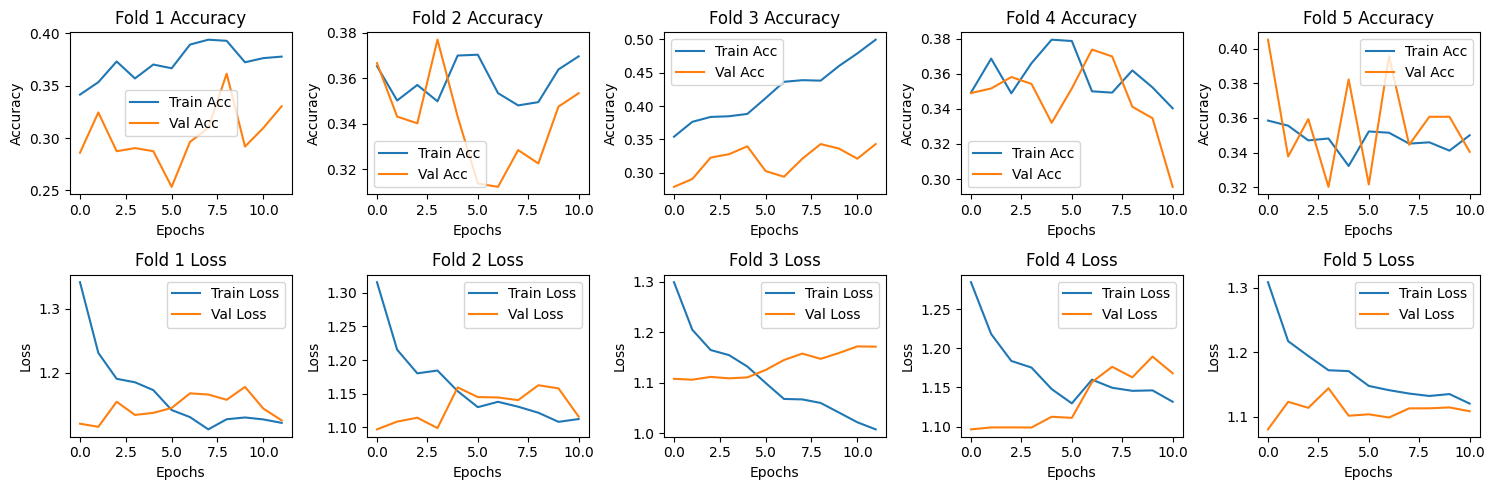

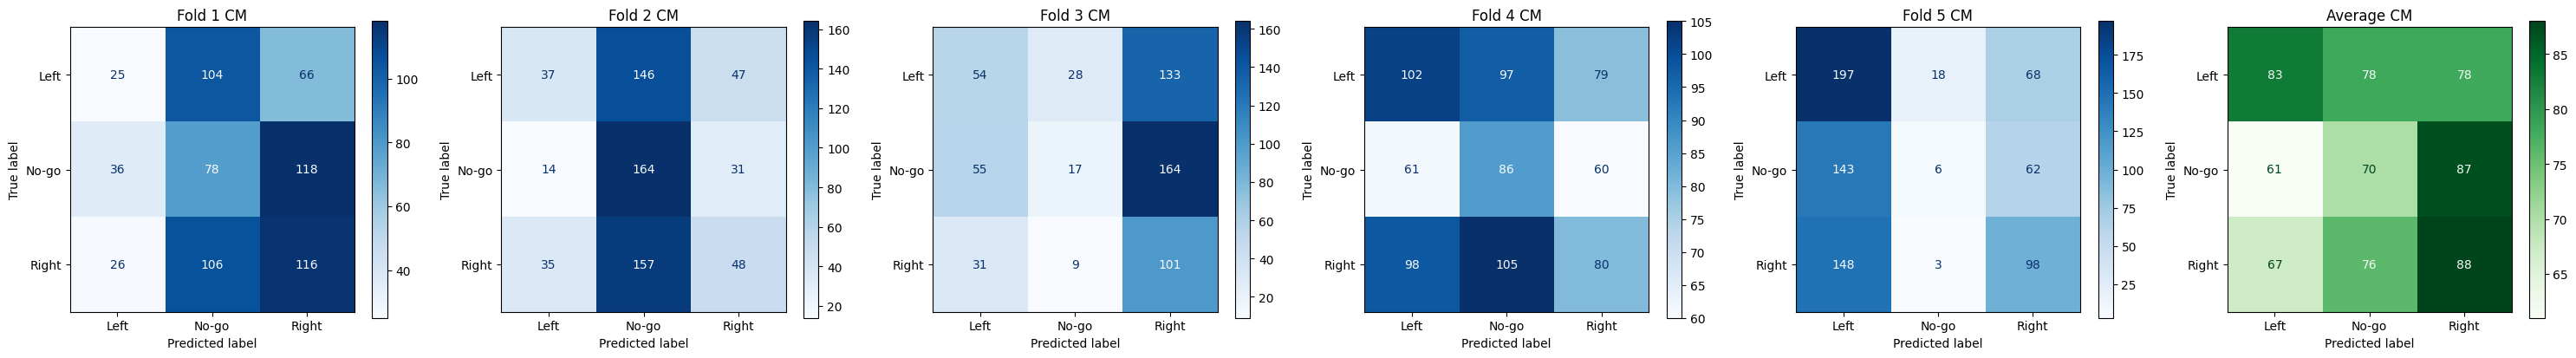

Script analysis section completed.


In [9]:
# Cell 9: Cross-Validation Summary (or Cell 11 in your execution)
print("\n\n--- Cross-Validation Summary ---")
if fold_val_losses: # <--- CORRECTED: Use fold_val_losses
    print(f"Average Validation Loss across {N_SPLITS_CV} folds: {np.nanmean(fold_val_losses):.4f} (+/- {np.nanstd(fold_val_losses):.4f})") # <--- CORRECTED
    print(f"Average Validation Accuracy across {N_SPLITS_CV} folds: {np.nanmean(fold_val_accuracies):.4f} (+/- {np.nanstd(fold_val_accuracies):.4f})") # <--- CORRECTED
else:
    print("No validation metrics recorded. Check the training loop.")

# Also ensure other parts of this cell use the correct list names populated in Cell 8:
# all_y_true_fold, all_y_pred_fold (for the overall classification report)
# fold_histories (for plotting training history)
# all_confusion_matrices (for plotting confusion matrices)

if all_y_true_fold: 
    print("\nOverall Classification Report (Aggregated over all folds):")
    print(classification_report(all_y_true_fold, all_y_pred_fold, target_names=['Left', 'No-go', 'Right'], zero_division=0))
else:
    print("No true/predicted labels recorded for overall classification report.")

if fold_histories:
    plt.figure(figsize=(15, 5 * ((len(fold_histories) + N_SPLITS_CV -1) // N_SPLITS_CV) )) 
    num_plot_rows = 2 # Assuming 2 rows for accuracy and loss plots
    for i, history_fold in enumerate(fold_histories):
        plt.subplot(num_plot_rows, N_SPLITS_CV, i + 1)
        plt.plot(history_fold.history['accuracy'], label='Train Acc')
        plt.plot(history_fold.history['val_accuracy'], label='Val Acc')
        plt.title(f'Fold {i+1} Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.subplot(num_plot_rows, N_SPLITS_CV, i + 1 + N_SPLITS_CV)
        plt.plot(history_fold.history['loss'], label='Train Loss')
        plt.plot(history_fold.history['val_loss'], label='Val Loss')
        plt.title(f'Fold {i+1} Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training histories recorded.")

if all_confusion_matrices:
    # Make sure to import ConfusionMatrixDisplay if you haven't already
    # from sklearn.metrics import ConfusionMatrixDisplay 
    fig_cm, axes_cm = plt.subplots(1, N_SPLITS_CV + 1, figsize=(5 * (N_SPLITS_CV + 1), 4))
    for i, cm_data in enumerate(all_confusion_matrices):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_data, display_labels=['Left', 'No-go', 'Right'])
        disp.plot(ax=axes_cm[i], cmap='Blues', values_format='d')
        axes_cm[i].set_title(f'Fold {i+1} CM')

    avg_cm = np.mean(all_confusion_matrices, axis=0).astype(int)
    disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Left', 'No-go', 'Right'])
    disp_avg.plot(ax=axes_cm[N_SPLITS_CV], cmap='Greens', values_format='d')
    axes_cm[N_SPLITS_CV].set_title('Average CM')
    plt.tight_layout()
    plt.show()
else:
    print("No confusion matrices recorded.")

print("Script analysis section completed.")
